https://blog.roboflow.com/camera-calibration-sports-computer-vision/

Utilizing this for keypoint detection attempts

Keypoints:

left_baseline_bottom_3p_line
left_baseline_top_3p_line
left_corner_bottom_3p_line
left_corner_top_3p_line
left_wing_bottom_3p_line
left_wing_top_3p_line
left_center_bottom_3p_line
left_center_top_3p_line
left_3p_center
left_baseline_bottom_ft_line
left_baseline_top_ft_line
left_baseline_bottom_corner
left_baseline_top_corner
left_bottom_paint_area
left_top_paint_area
left_bottom_ft_corner
left_top_ft_corner
left_ft_center
left_bottom_halfcourt_sideline
left_top_halfcourt_sideline

top_half_court
top_middle_half_court
center_half_court
bottom_middle_half_court
bottom_half_court
right_halfcourt_symbol
left_halfcourt_symbol


right_baseline_bottom_3p_line
right_baseline_top_3p_line
right_corner_bottom_3p_line
right_corner_top_3p_line
right_wing_bottom_3p_line
right_wing_top_3p_line
right_center_bottom_3p_line
right_center_top_3p_line
right_3p_center
right_baseline_bottom_ft_line
right_baseline_top_ft_line
right_baseline_bottom_corner
right_baseline_top_corner
right_bottom_paint_area
right_top_paint_area
right_bottom_ft_corner
right_top_ft_corner
right_ft_center
right_bottom_halfcourt_sideline
right_top_halfcourt_sideline


my roboflow dataset: https://app.roboflow.com/basketball-formations/basketball_court_keypoint/3/export

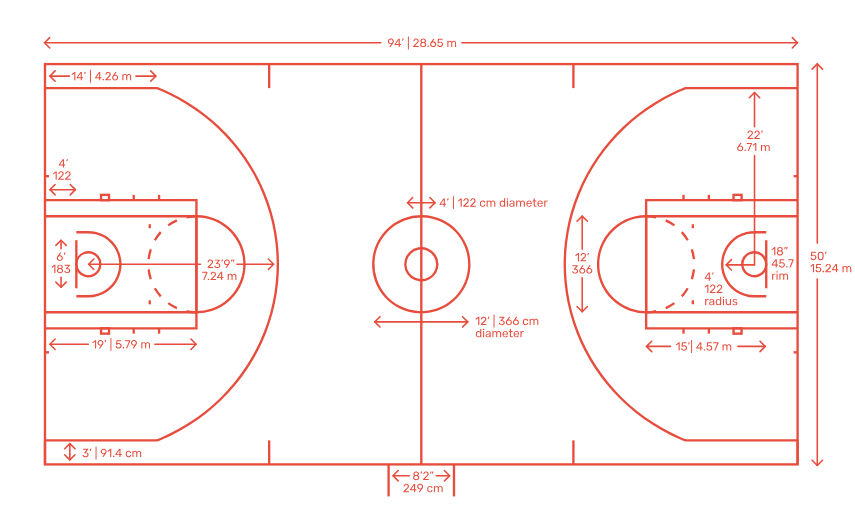

In [5]:
import os
import requests
import torch
from roboflow import Roboflow
import cv2
import supervision as sv
import yaml
import numpy as np
from pytube import YouTube
import shutil
from IPython.display import display, Image
import random


# Check GPU availability
print(torch.__version__)
print("CUDA available: ", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Define directories
HOME = "../"
print(HOME)
weights_dir = os.path.join(HOME, "data/models")
print(weights_dir)
os.makedirs(weights_dir, exist_ok=True)
images_dir = os.path.join(HOME, "data/images")
print(images_dir)
os.makedirs(images_dir, exist_ok=True)


def get_classes_and_update_paths(dataset_location):
    # Check the directory structure to confirm the location of data.yaml
    found_yaml = False
    for root, dirs, files in os.walk(dataset_location):
        if "data.yaml" in files:
            found_yaml = True
            data_yaml_path = os.path.join(root, "data.yaml")
            break  # No need to continue after finding the YAML
    
    if not found_yaml:
        raise FileNotFoundError(f"data.yaml not found in {dataset_location}. Please check the dataset structure.")
    
    # Load the YAML file
    with open(data_yaml_path, 'r') as file:
        data_yaml = yaml.safe_load(file)
    
    # Extract the dataset folder name dynamically
    project_name = os.path.basename(os.path.normpath(dataset_location))
    
    # Update to the correct location dynamically using the dataset folder name
    data_yaml['train'] = f'/workspaces/basketball_homography/data/images/{project_name}/train/images'
    data_yaml['val'] = f'/workspaces/basketball_homography/data/images/{project_name}/valid/images'
    data_yaml['test'] = f'/workspaces/basketball_homography/data/images/{project_name}/test/images'
    
    # Save the modified YAML file
    with open(data_yaml_path, 'w') as file:
        yaml.safe_dump(data_yaml, file)
    
    # Return class names from YAML
    class_names = data_yaml['names']
    print("Roboflow classes = ", class_names)
    print("dataset location = ", dataset_location)
    print("data_yaml_path = ", data_yaml_path)
    
    return class_names, data_yaml_path, dataset_location

version = 8
path_to_images = f"../data/images/basketball_court_keypoint-{version}"
class_names, data_yaml_path, dataset_location = get_classes_and_update_paths(path_to_images)

2.4.1+cu121
CUDA available:  True
Using device: cuda
../
../data/models
../data/images
Roboflow classes =  ['full_court']
dataset location =  ../data/images/basketball_court_keypoint-8
data_yaml_path =  ../data/images/basketball_court_keypoint-8/data.yaml


In [6]:
# Remove previous run files if they exist
runs_dir = os.path.join(HOME, "runs")
if os.path.exists(runs_dir):
   shutil.rmtree(runs_dir)
   print(f"Removed previous run files in {runs_dir}")
print(os.getcwd())
print(data_yaml_path)
print(os.path.join(weights_dir, "yolov10x.pt"))
# Custom training50
os.system(f'yolo task=pose mode=train epochs=15   batch=8 plots=True model={os.path.join("/workspaces/basketball_homography/data/models/yolov8x-pose.pt")} data={data_yaml_path} device={device} workers=1')


/workspaces/basketball_homography/notebooks
../data/images/basketball_court_keypoint-8/data.yaml
../data/models/yolov10x.pt
New https://pypi.org/project/ultralytics/8.2.102 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.98 🚀 Python-3.10.15 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine/trainer: task=pose, mode=train, model=/workspaces/basketball_homography/data/models/yolov8x-pose.pt, data=../data/images/basketball_court_keypoint-8/data.yaml, epochs=15, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=1, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7,

train: Scanning /workspaces/basketball_homography/data/images/basketball_court_keypoint-8/train/labels.cache... 121 images, 1 backgrounds, 2 corrupt: 100%|██████████| 121/121 [00:00<?, ?it/s]


train: WARNING ⚠️ /workspaces/basketball_homography/data/images/basketball_court_keypoint-8/train/images/yt-9SjvZPFiDH0-0009_jpg.rf.e0fca54eb6419bdb634cdefbb8d5b0c8.jpg: ignoring corrupt image/label: negative label values [ -0.0022322]
train: WARNING ⚠️ /workspaces/basketball_homography/data/images/basketball_court_keypoint-8/train/images/yt-eLF46VmxXxI-0034_jpg.rf.0ac057725bf89a23bac9ab960c62e6f4.jpg: ignoring corrupt image/label: negative label values [ -0.0022322]


val: Scanning /workspaces/basketball_homography/data/images/basketball_court_keypoint-8/valid/labels.cache... 31 images, 0 backgrounds, 1 corrupt: 100%|██████████| 31/31 [00:00<?, ?it/s]


val: WARNING ⚠️ /workspaces/basketball_homography/data/images/basketball_court_keypoint-8/valid/images/yt-eLF46VmxXxI-0001_jpg.rf.941c2bf8916e3f4c4ed6b04361684c7b.jpg: ignoring corrupt image/label: negative label values [ -0.0066964  -0.0066964  -0.0066964]
Plotting labels to runs/pose/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 103 weight(decay=0.0), 113 weight(decay=0.0005), 112 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 1 dataloader workers
Logging results to runs/pose/train
Starting training for 15 epochs...

      Epoch    GPU_mem   box_loss  pose_loss  kobj_loss   cls_loss   dfl_loss  Instances       Size


...

      15/15      7.64G     0.2536      11.34     0.6348     0.3442      1.163          7        640: 100%|██████████| 15/15 [00:02<00:00,  6.41it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  7.39it/s]


                   all         30         30      0.997          1      0.995      0.911          0          0          0          0

15 epochs completed in 0.027 hours.
Optimizer stripped from runs/pose/train/weights/last.pt, 142.1MB
Optimizer stripped from runs/pose/train/weights/best.pt, 142.1MB

Validating runs/pose/train/weights/best.pt...
Ultralytics YOLOv8.2.98 🚀 Python-3.10.15 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLOv8x-pose summary (fused): 287 layers, 70,821,507 parameters, 0 gradients, 269.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.72it/s]


                   all         30         30      0.998          1      0.995      0.931          0          0          0          0
Speed: 1.2ms preprocess, 13.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/pose/train
💡 Learn more at https://docs.ultralytics.com/modes/train


0

results_dir = runs/pose/train
best_model_path = runs/pose/train/weights/best.pt


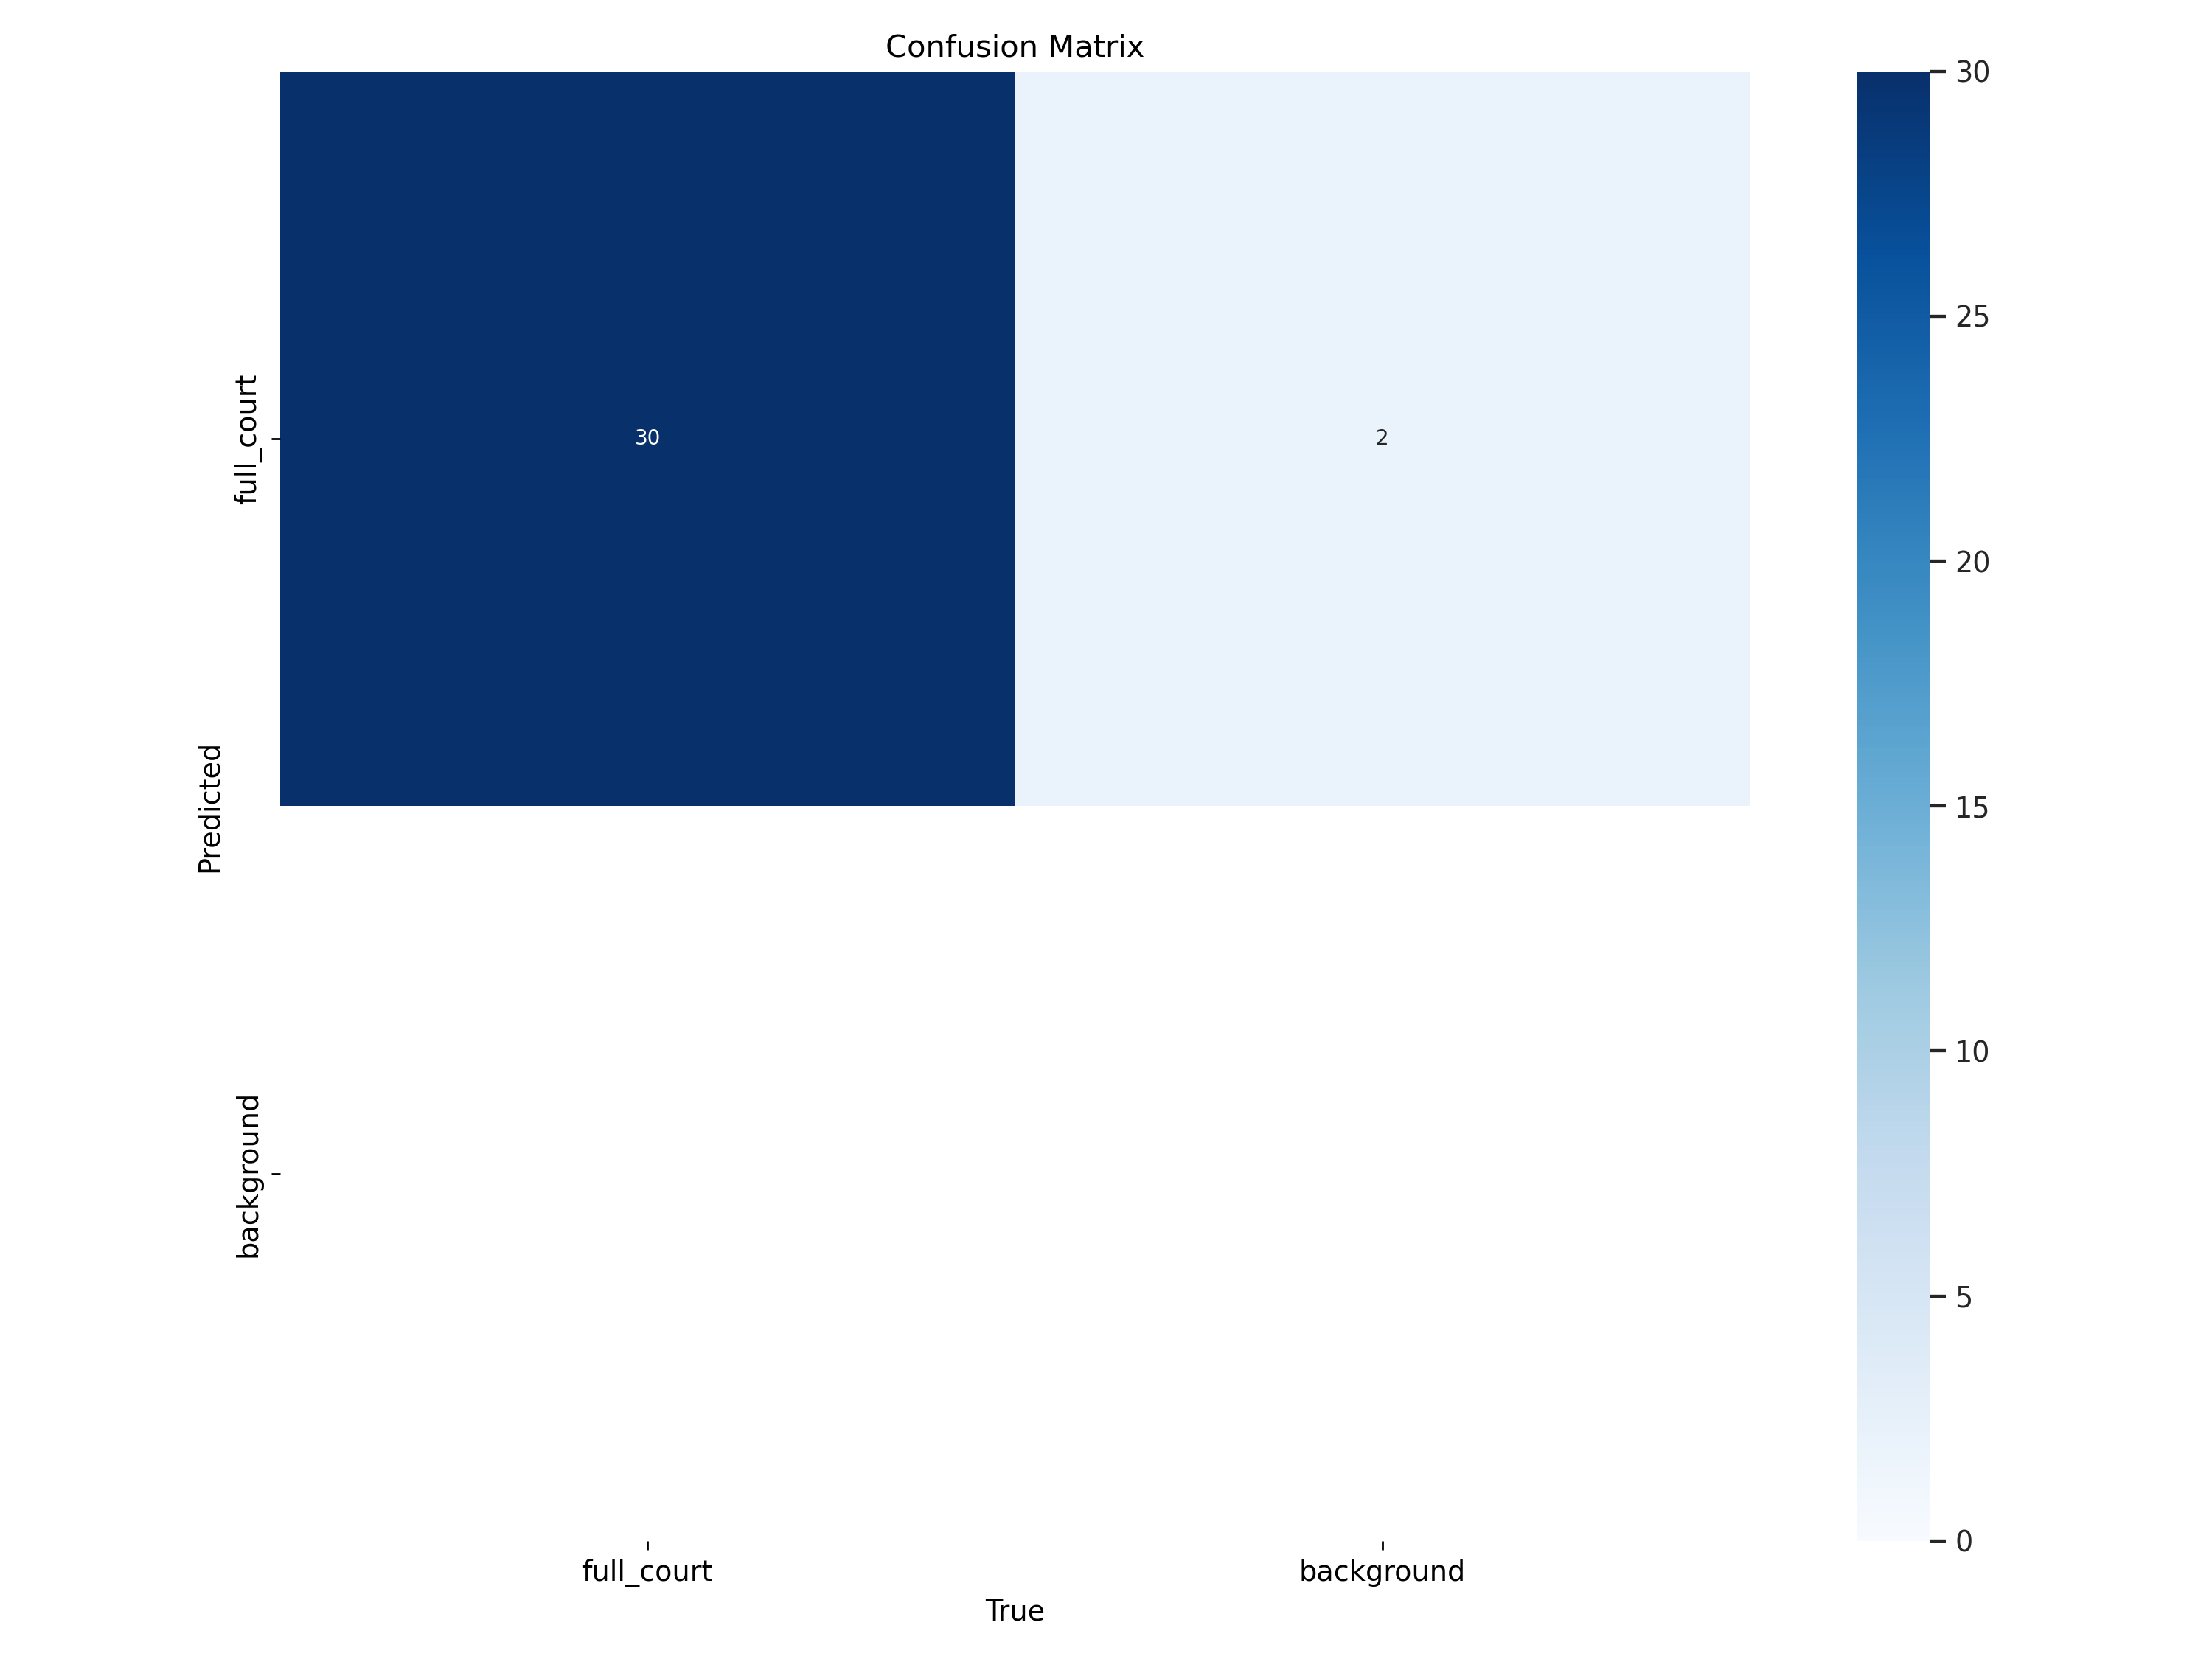

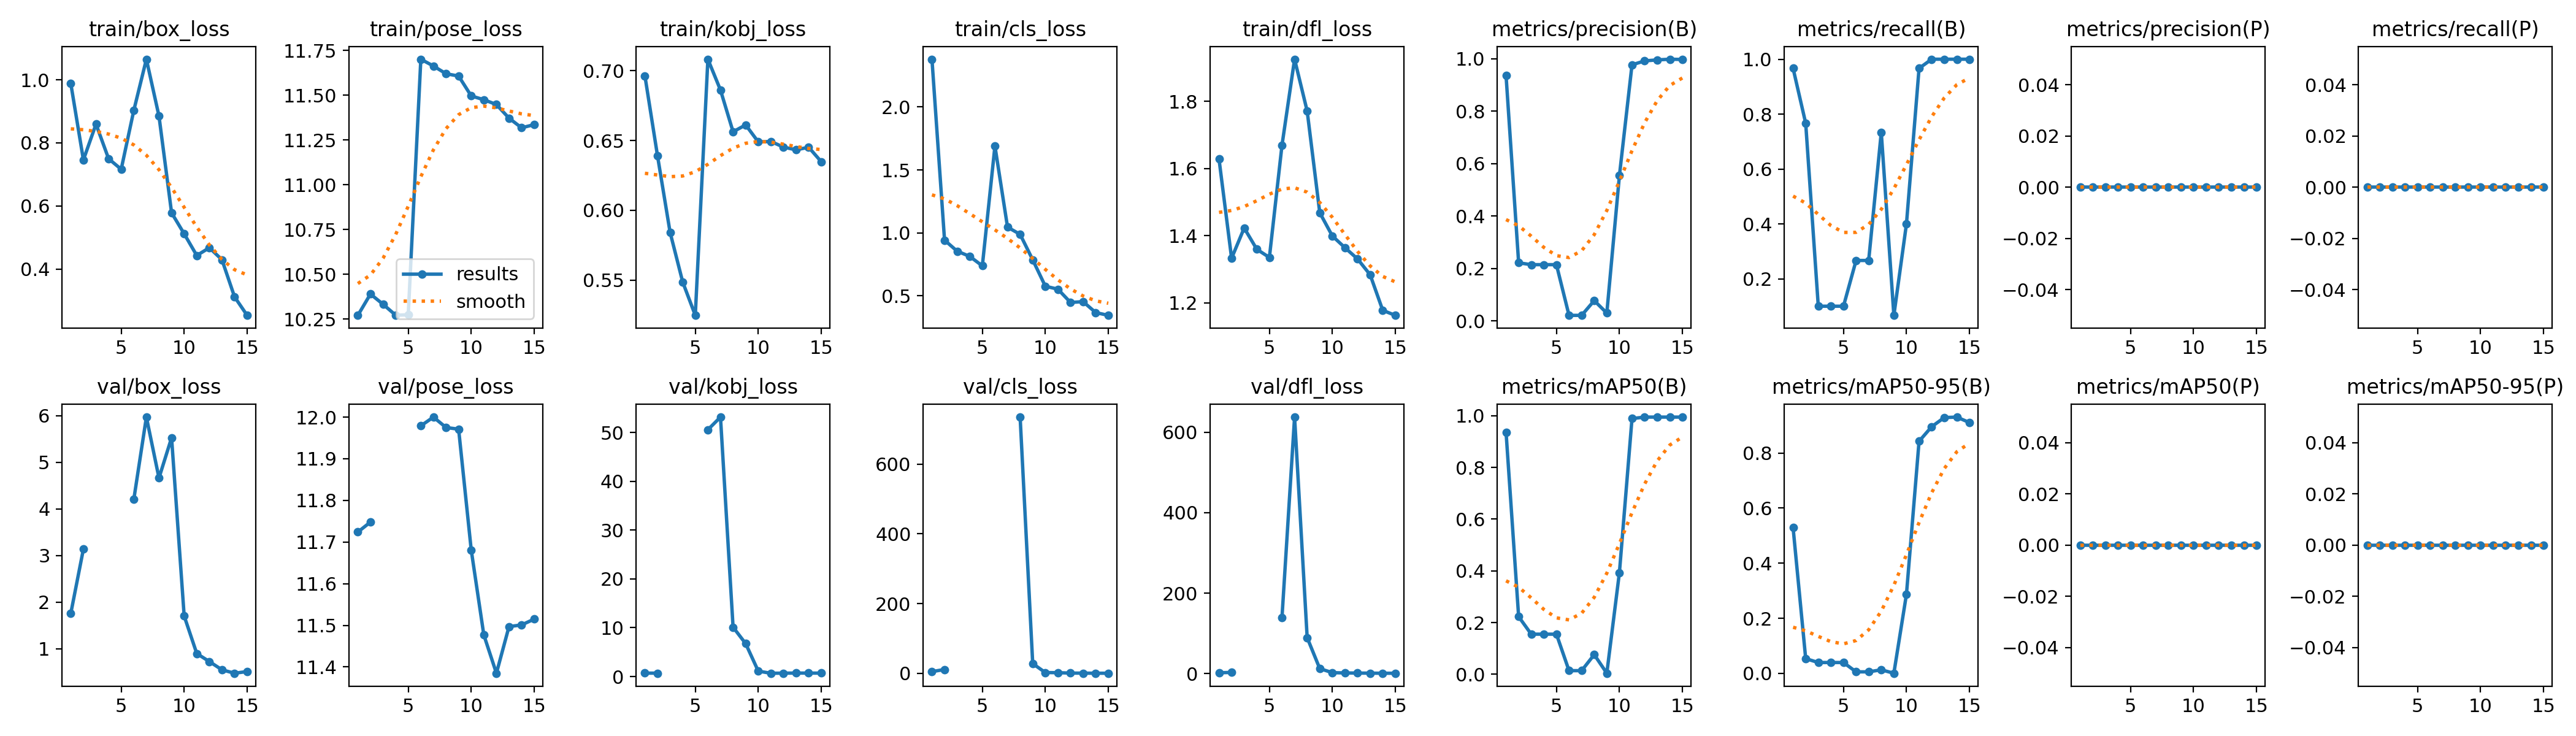

Trained model files:
best.pt
last.pt


In [7]:
# Post-training results
results_dir = os.path.join("runs", "pose", "train")
print("results_dir =", results_dir)
best_model_path = os.path.join(results_dir, "weights", "best.pt")
print("best_model_path =", best_model_path)
if os.path.exists(results_dir):
    display(Image(filename=os.path.join(results_dir, "confusion_matrix.png"), width=600))
    display(Image(filename=os.path.join(results_dir, "results.png"), width=600))
    
    # Display model files
    print("Trained model files:")
    for file_name in os.listdir(os.path.join(results_dir, "weights")):
        if file_name.endswith(".pt"):
            print(file_name)



0: 352x640 2 full_courts, 41.2ms
Speed: 1.8ms preprocess, 41.2ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)


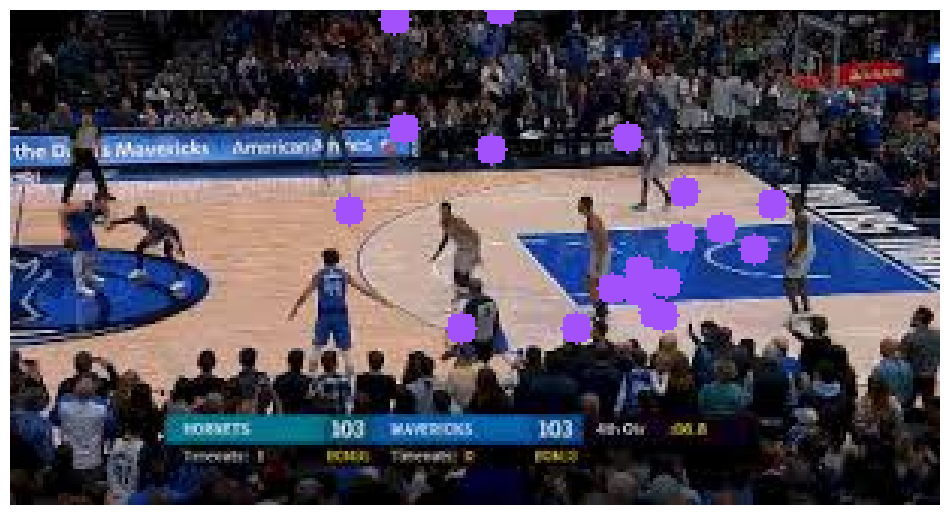

In [8]:
import cv2
from ultralytics import YOLO

model = YOLO('runs/pose/train/weights/best.pt')

image_path = "../data/images/luka.jpg"
image = cv2.imread(image_path)
result = model(image)[0]
keypoints = sv.KeyPoints.from_ultralytics(result)


filter = keypoints.confidence > 0.5
keypoints.xy = keypoints.xy[filter][np.newaxis]
keypoints.confidence = keypoints.confidence[filter][np.newaxis]

vertex_annotator = sv.VertexAnnotator(radius=5)
annotated_image = vertex_annotator.annotate(image.copy(), keypoints)

sv.plot_image(annotated_image)

# deploying keypoint on different devices:

https://docs.roboflow.com/deploy/hosted-api/custom-models/keypoint-detection